In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl
from itertools import product

import missingno

# Process maize data

In [2]:
data = pd.read_pickle('data/raw/data-maize-lineariterpwth.pkl')
# Drop rows with no production data
data = data.loc[data.maizeprodkg_ha.notna()]
metadata = pd.read_csv('data/raw/05_FMBA24sf2_meta_250620.csv', sep='\t')
metadata = metadata.set_index('colname')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1917 entries, 0 to 3753
Data columns (total 100 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   maizeprodkg_ha                      1917 non-null   float64
 1   maizemarketing                      1917 non-null   object 
 2   maizeharvest_seperate               1917 non-null   object 
 3   maizeharvestsheller                 1917 non-null   object 
 4   maizevariety                        1917 non-null   object 
 5   maizerecycledseed                   1917 non-null   object 
 6   maizefieldprep                      1917 non-null   object 
 7   maizeplantingmethod                 1917 non-null   object 
 8   maizeplantmonth                     1917 non-null   object 
 9   maizeplantmonthpart                 1917 non-null   object 
 10  maizedryplant                       1779 non-null   object 
 11  maizePdeficiency                    1917 non-nu

## Impute missing fertilizer data

Some of the Fertilizer information is missing. Let's see if we can fill that in. First look into the missing data patterns:

<Axes: >

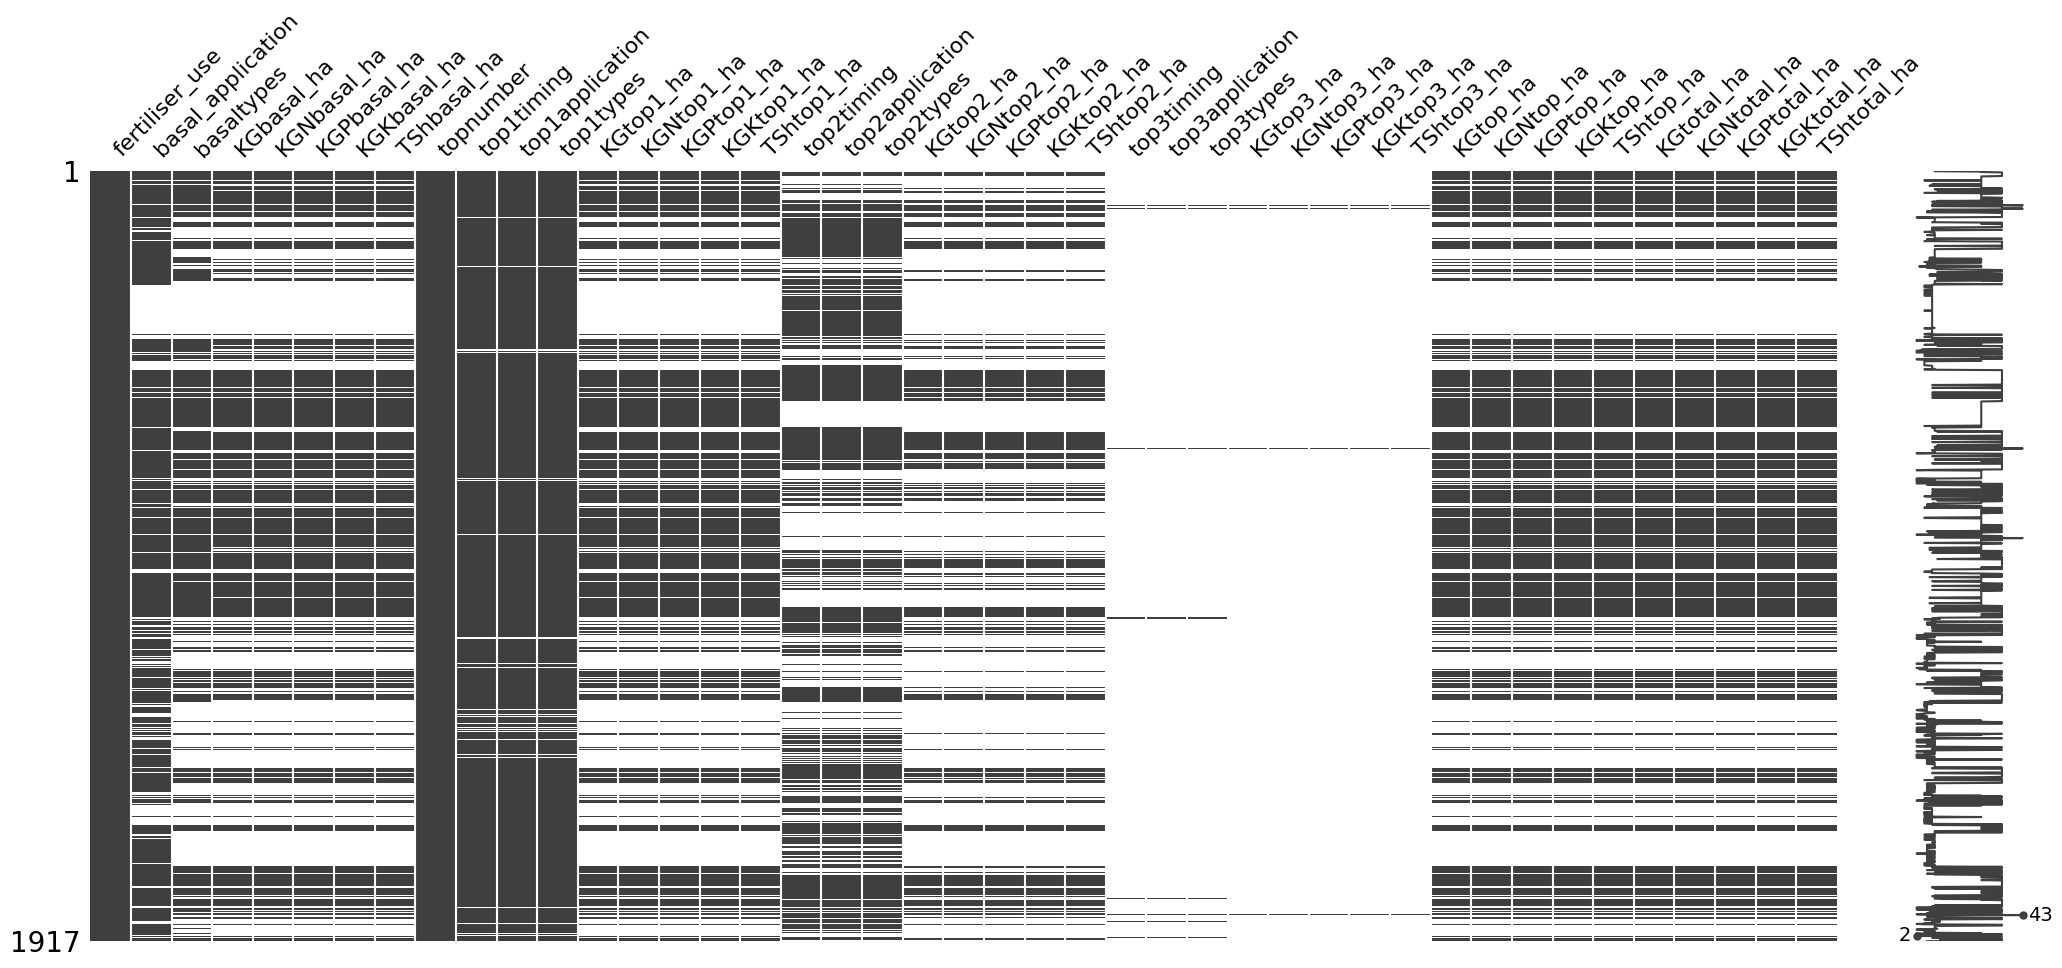

In [4]:
missingno.matrix(data[data.columns[20:63]])

In [5]:
# Check if the KGTotal_ha column is the same as the sum of the other KGN columns
fert_sum = data[['KGNbasal_ha', 'KGNtop1_ha', 'KGNtop2_ha', 'KGNtop3_ha']].sum(axis=1)
fert_sum = fert_sum.where(~data[['KGNbasal_ha', 'KGNtop1_ha', 'KGNtop2_ha', 'KGNtop3_ha']].isna().all(axis=1), None)
# Same NaN values, and same values?
(fert_sum.isna() == data.KGNtotal_ha.isna()).all(), \
    np.isclose(fert_sum.dropna(), data.KGNtotal_ha.dropna()).all()

(np.True_, np.True_)

In [6]:
# Check if all basal amounts are complete
((~data.basal_application.isin([None, 'none', np.nan])) == data.KGNbasal_ha.replace(0, None).notna()).all()

np.False_

Fertilizer information is important. We will impute the fertilizer amount values when fertilizer use was reported but amount was not. 
We will impute those amounts using a regressor trained on other variables.

In [7]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor

In [8]:
# Impute missing basal N amounts
def impute_missing_fert(fertappl:str):
    appl_var = f'{fertappl}{"_" if fertappl == "basal" else ""}application'
    amnt_var = f'KGN{fertappl}_ha'
    categorical_features = [
        'maizevariety', 'maizefieldprep', 'maizeplantingmethod',
        'maizeplantmonth', 'FRMRgender', 
    ]
    numeric_features = [
        'maizeprodkg_ha', 'carbon_organic_mean_0_20', 'harvestarea_ha',
        'clay_content_mean_0_20', 'sand_content_mean_0_20'
    ]
    appl_mask = ~data[appl_var].isin([None, 'none', np.nan])
    tmp_df = data.loc[appl_mask, categorical_features+numeric_features+[appl_var, amnt_var]]
    
    train_df = tmp_df.loc[tmp_df[amnt_var].replace(0, None).notna()]
    
    X = train_df[categorical_features+numeric_features]
    y = train_df[amnt_var]
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())                 
    ])
    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop' 
    )
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestRegressor())
    ])
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model_pipeline, X, y, cv=cv, scoring='r2')
    print(scores)
    predict_df = tmp_df.loc[~tmp_df.index.isin(train_df.index)]
    if np.isnan(scores).any() or (scores.mean() < 0):
        imputed = pd.Series(
            train_df[amnt_var].mean(),
            index=predict_df.index
        )
        return imputed
    model_pipeline.fit(X, y)
    imputed = pd.Series(
        model_pipeline.predict(predict_df),
        index=predict_df.index
    )
    return imputed

Impute basal

In [9]:
imputed = impute_missing_fert("basal")
data.loc[imputed.index, 'KGNbasal_ha'] = imputed
((~data.basal_application.isin([None, 'none', np.nan])) == data.KGNbasal_ha.replace(0, None).notna()).all()

[0.24923958 0.20183965 0.16527121 0.15179167 0.11698534]


np.True_

In [10]:
data['KGNbasal_ha'] = data.KGNbasal_ha.fillna(0)

Check and impute Top 1

In [11]:
((~data.top1application.isin([None, 'none', np.nan])) == data.KGNtop1_ha.replace(0, None).notna()).all()

np.False_

In [12]:
imputed = impute_missing_fert("top1")
data.loc[imputed.index, 'KGNtop1_ha'] = imputed
((~data.top1application.isin([None, 'none', np.nan])) == data.KGNtop1_ha.replace(0, None).notna()).all()

[0.23372958 0.32520514 0.17602367 0.26744308 0.22213768]


np.True_

In [13]:
data['KGNtop1_ha'] = data.KGNtop1_ha.fillna(0)

Check and impute Top 2

In [14]:
((~data.top2application.isin([None, 'none', np.nan])) == data.KGNtop2_ha.replace(0, None).notna()).all()

np.False_

In [15]:
imputed = impute_missing_fert("top2")
data.loc[imputed.index, 'KGNtop2_ha'] = imputed
((~data.top2application.isin([None, 'none', np.nan])) == data.KGNtop2_ha.replace(0, None).notna()).all()

[0.30021846 0.24647622 0.22528076 0.29019103 0.12971118]


np.True_

In [16]:
data['KGNtop2_ha'] = data.KGNtop2_ha.fillna(0)

Check and impute Top 3

In [17]:
((~data.top3application.isin([None, 'none', np.nan])) == data.KGNtop3_ha.replace(0, None).notna()).all()

np.False_

In [18]:
imputed = impute_missing_fert("top3")
data.loc[imputed.index, 'KGNtop3_ha'] = imputed
((~data.top3application.isin([None, 'none', np.nan])) == data.KGNtop3_ha.replace(0, None).notna()).all()

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


[nan nan nan nan nan]


/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


np.True_

In [19]:
data['KGNtop3_ha'] = data.KGNtop3_ha.fillna(0)

## Create the final dataframe

This dataframe will have the columns that will potentetially be used in the analysis.

In [20]:
soil_columns = [
    'nitrogen_total_mean_0_20', 'clay_content_mean_0_20',
    'sand_content_mean_0_20', 'bulk_density_mean_0_20',
    'cation_exchange_capacity_mean_0_20', 'ph_mean_0_20',
    'carbon_organic_mean_0_20'
]
weather_columns = [
    'season_tmin', 'season_tmean', 'season_tmax', 'season_srad',
    'season_prec', 'season_rainydays', 'season_maxdryspell',
    'season_avgdryspell', 
]
numeric_columns = [
    'maizeprodkg_ha', 'maizeweedings',  
] + soil_columns + weather_columns

data_subset = data[numeric_columns + ['previousadvice']].copy()
data_subset['previousadvice'] = (data_subset.previousadvice == 'yes')

data_subset['genderfemale'] = pd.get_dummies(data.FRMRgender, drop_first=True)
data_subset['fieldsize'] = data.harvestarea_ha
data_subset = data_subset.join( # handhoe, ploughcattle, tractor
    pd.get_dummies(data.maizefieldprep, prefix='tech', drop_first=False, prefix_sep='').iloc[:, [0,2,3]] 
)
most_common_varieties = [
    'SC719', 'PAN691', 'SC627', 'LOCAL_VARIETY', 'DKC9089', 'SC403',
    'PAN53', 'UH6303', 'DK777', 'ZMS606', 'MERU_HB513', 'UH615'
]
data_subset = data_subset.join(
    pd.get_dummies(
        data.maizevariety.where(data.maizevariety.isin(most_common_varieties), '0_other'),
        prefix='var', drop_first=True, prefix_sep='' 
    )
)
data_subset = data_subset.join(
    pd.get_dummies(
        data.maizeresidues.where(
            data.maizeresidues.isin(['leave on field', 'burn', 'feed to animals', 'incorporate in the soil']), 
            '0_other'
        ),
        prefix='res', drop_first=True, prefix_sep='' 
    )
)
# Define crop history with crop groups based on how they affect soil and managmeent
crop_groups = {
    'legume': ['beans', 'groundnuts', 'pigeonpea', 'soya'],
    'rootandtuber': ['cassava', 'roundpotatoes', 'sweetpotatoes'],
    'oilseed': ['sesame', 'sunflower']
}

def get_group_history(history:str):
    hist = {
        'histmaize': 'maize' in history,
        'histnocrop': 'no_crop' in history
    }
    for group_name, crops in crop_groups.items():
        hist[f'hist{group_name}'] = any(map(lambda x: x in history, crops))
    return hist
    
data_subset = data_subset.join(
    pd.DataFrame.from_records(data.crophistory.map(get_group_history), index=data.index)
)

data_subset['herbicidepost'] = data.maizeherbicides.str.contains('post-emergence').astype(bool)
data_subset['herbicidepre'] = data.maizeherbicides.str.contains('pre-emergence').astype(bool)
data_subset['pestdisease'] = data.maizepestdisease != 'no'

data_subset['fertbasal'] = data.KGNbasal_ha
fertilizer_timings = [
    '5-6-leaves', 'knee-high', '8-10-leaves', 'emergence', 'tasseling', 'silking'
]
for timing in fertilizer_timings:
    data_subset.loc[:, f'fert{timing.replace("-", "")}'] = \
        np.where(data.top1timing == timing, data.KGNtop1_ha, 0) + \
        np.where(data.top2timing == timing, data.KGNtop2_ha, 0) + \
        np.where(data.top3timing == timing, data.KGNtop3_ha, 0)

data_subset.columns = data_subset.columns.str.lower().str.replace(' ', '')

In [21]:
data_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1917 entries, 0 to 3753
Data columns (total 54 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   maizeprodkg_ha                      1917 non-null   float64
 1   maizeweedings                       1917 non-null   float64
 2   nitrogen_total_mean_0_20            1917 non-null   float64
 3   clay_content_mean_0_20              1917 non-null   float64
 4   sand_content_mean_0_20              1917 non-null   float64
 5   bulk_density_mean_0_20              1917 non-null   float64
 6   cation_exchange_capacity_mean_0_20  1917 non-null   float64
 7   ph_mean_0_20                        1917 non-null   float64
 8   carbon_organic_mean_0_20            1917 non-null   float64
 9   season_tmin                         1917 non-null   float64
 10  season_tmean                        1917 non-null   float64
 11  season_tmax                         1917 non-nul

## Explore linear dependecies between variables

We will drop the variables that are a strongly correlated to other variables among their group of variables (Fertilizer info, weather, soil, etc.)

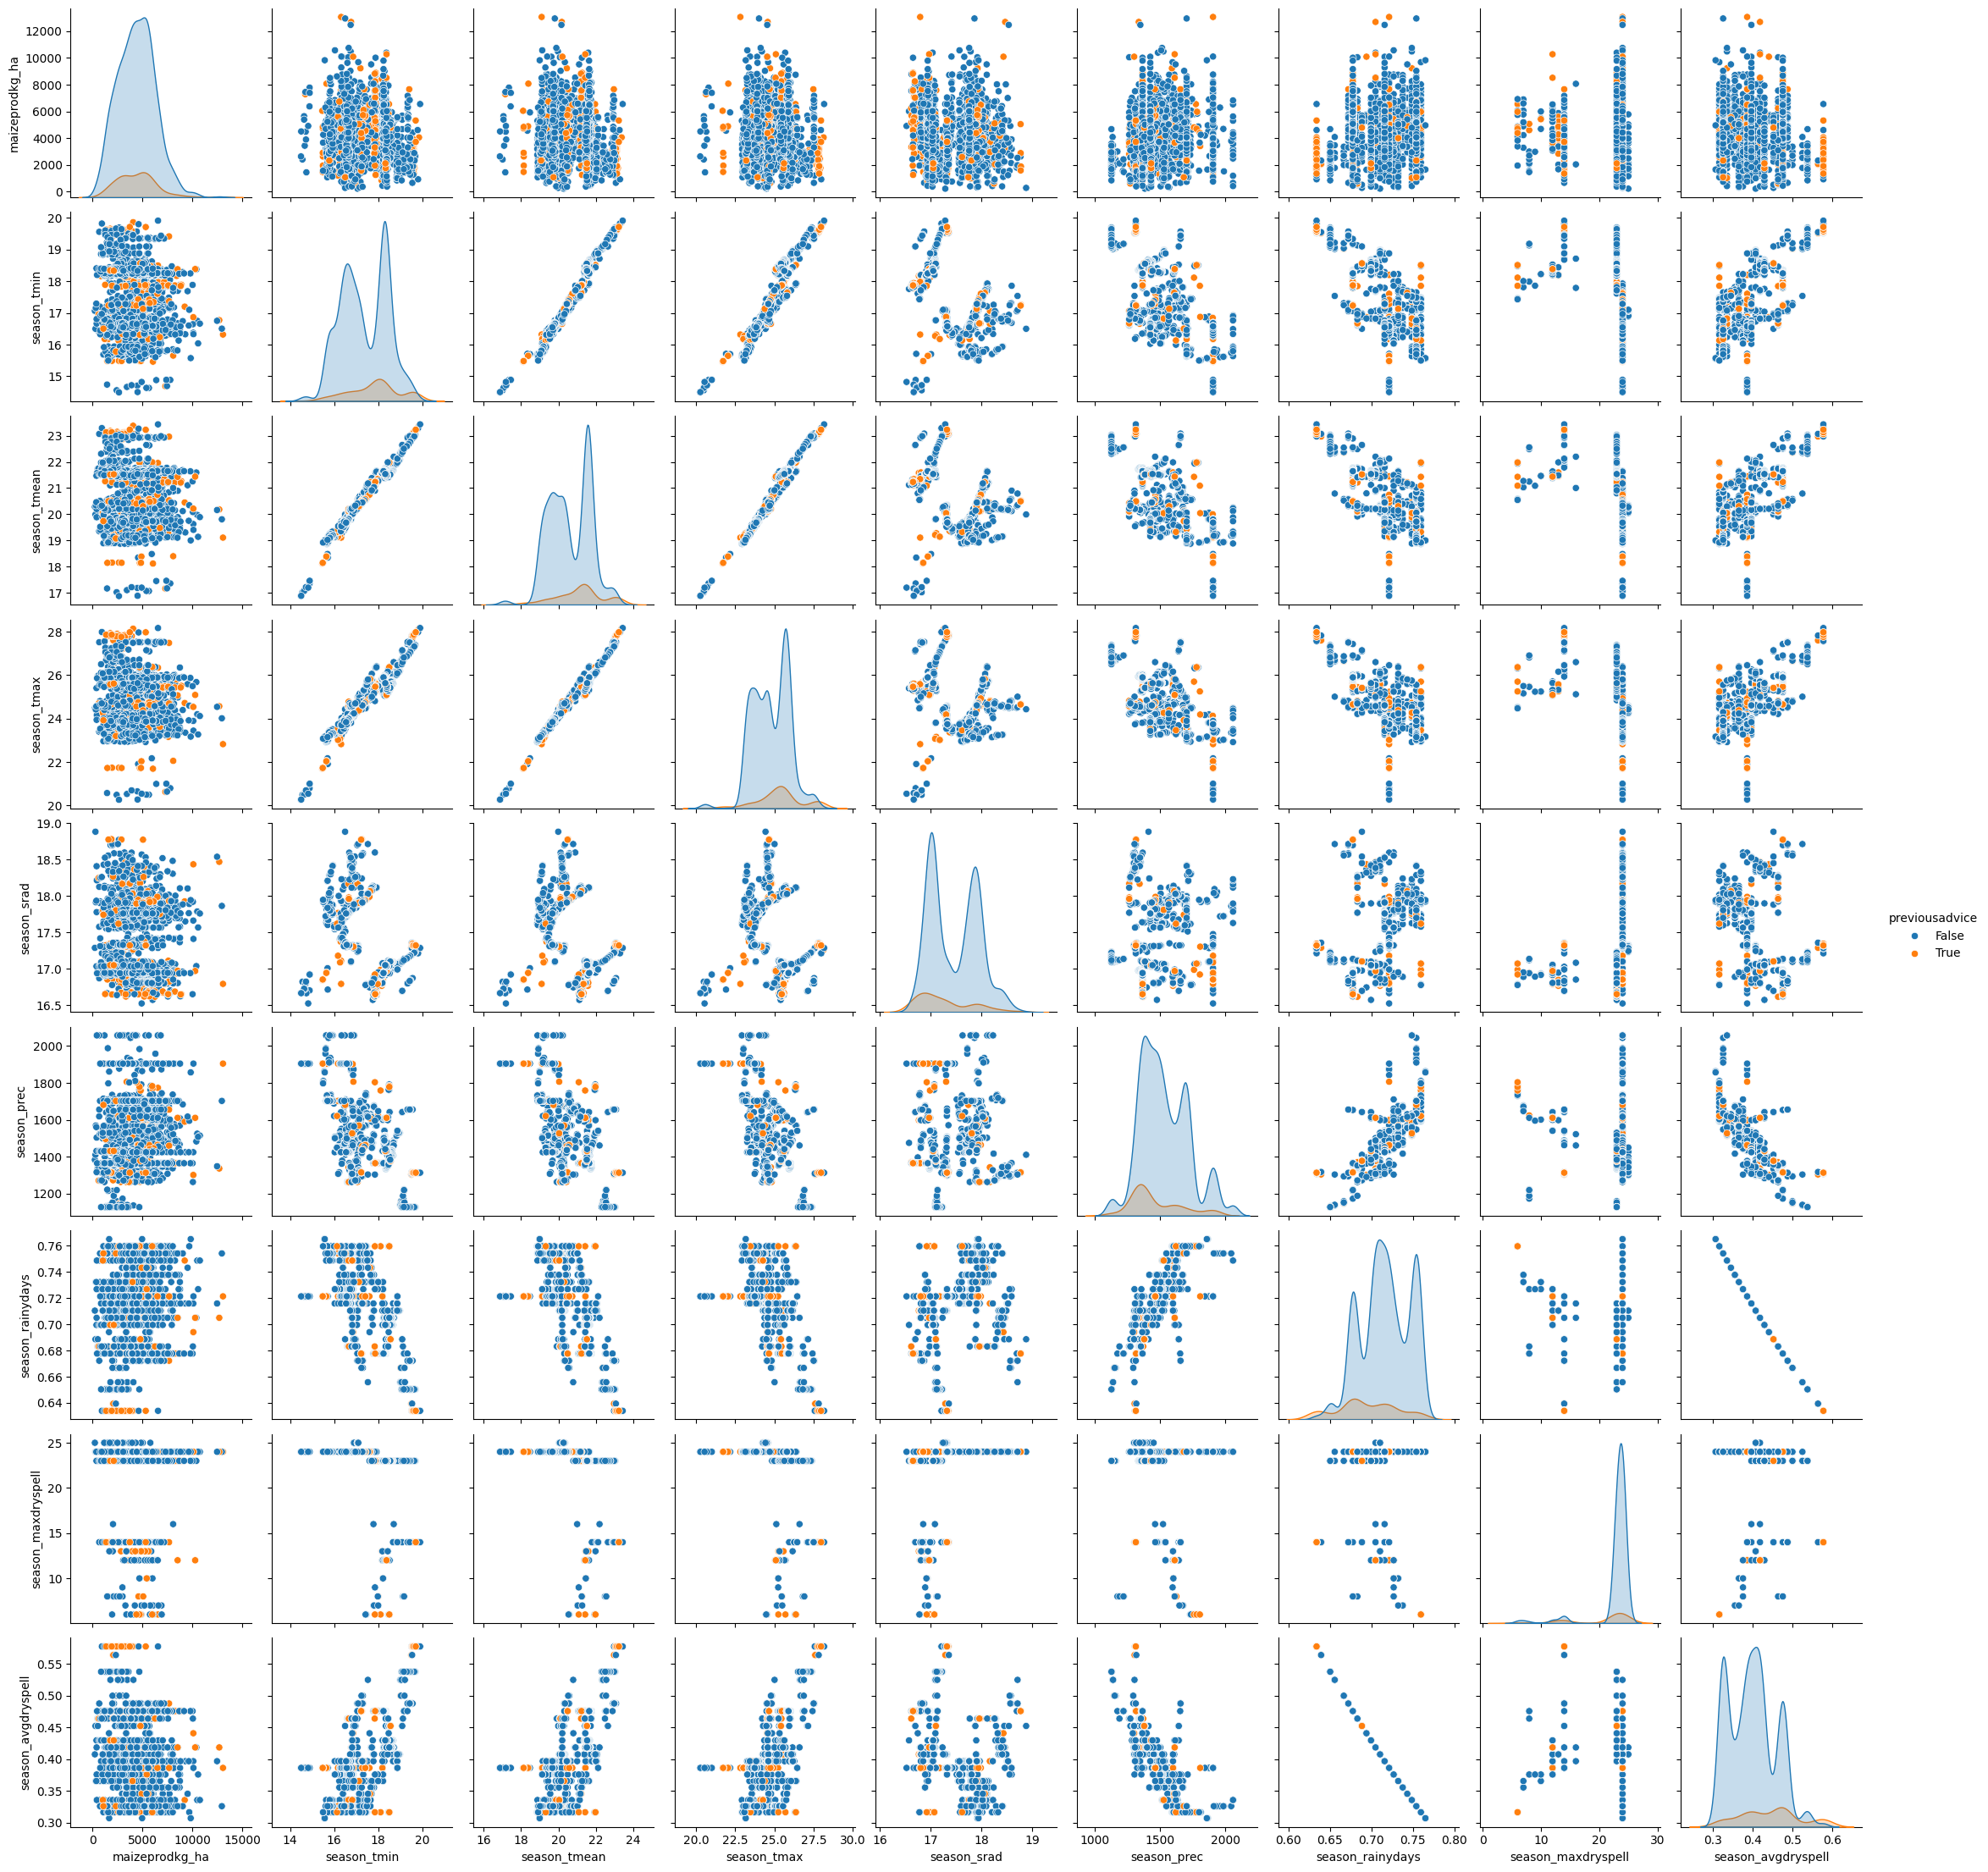

In [22]:
# Weather info
sns.pairplot(
    data=data_subset[['previousadvice', 'maizeprodkg_ha']+weather_columns],
    hue='previousadvice'
)

In [25]:
columns_to_drop = ['season_tmin', 'season_tmax', 'season_avgdryspell']

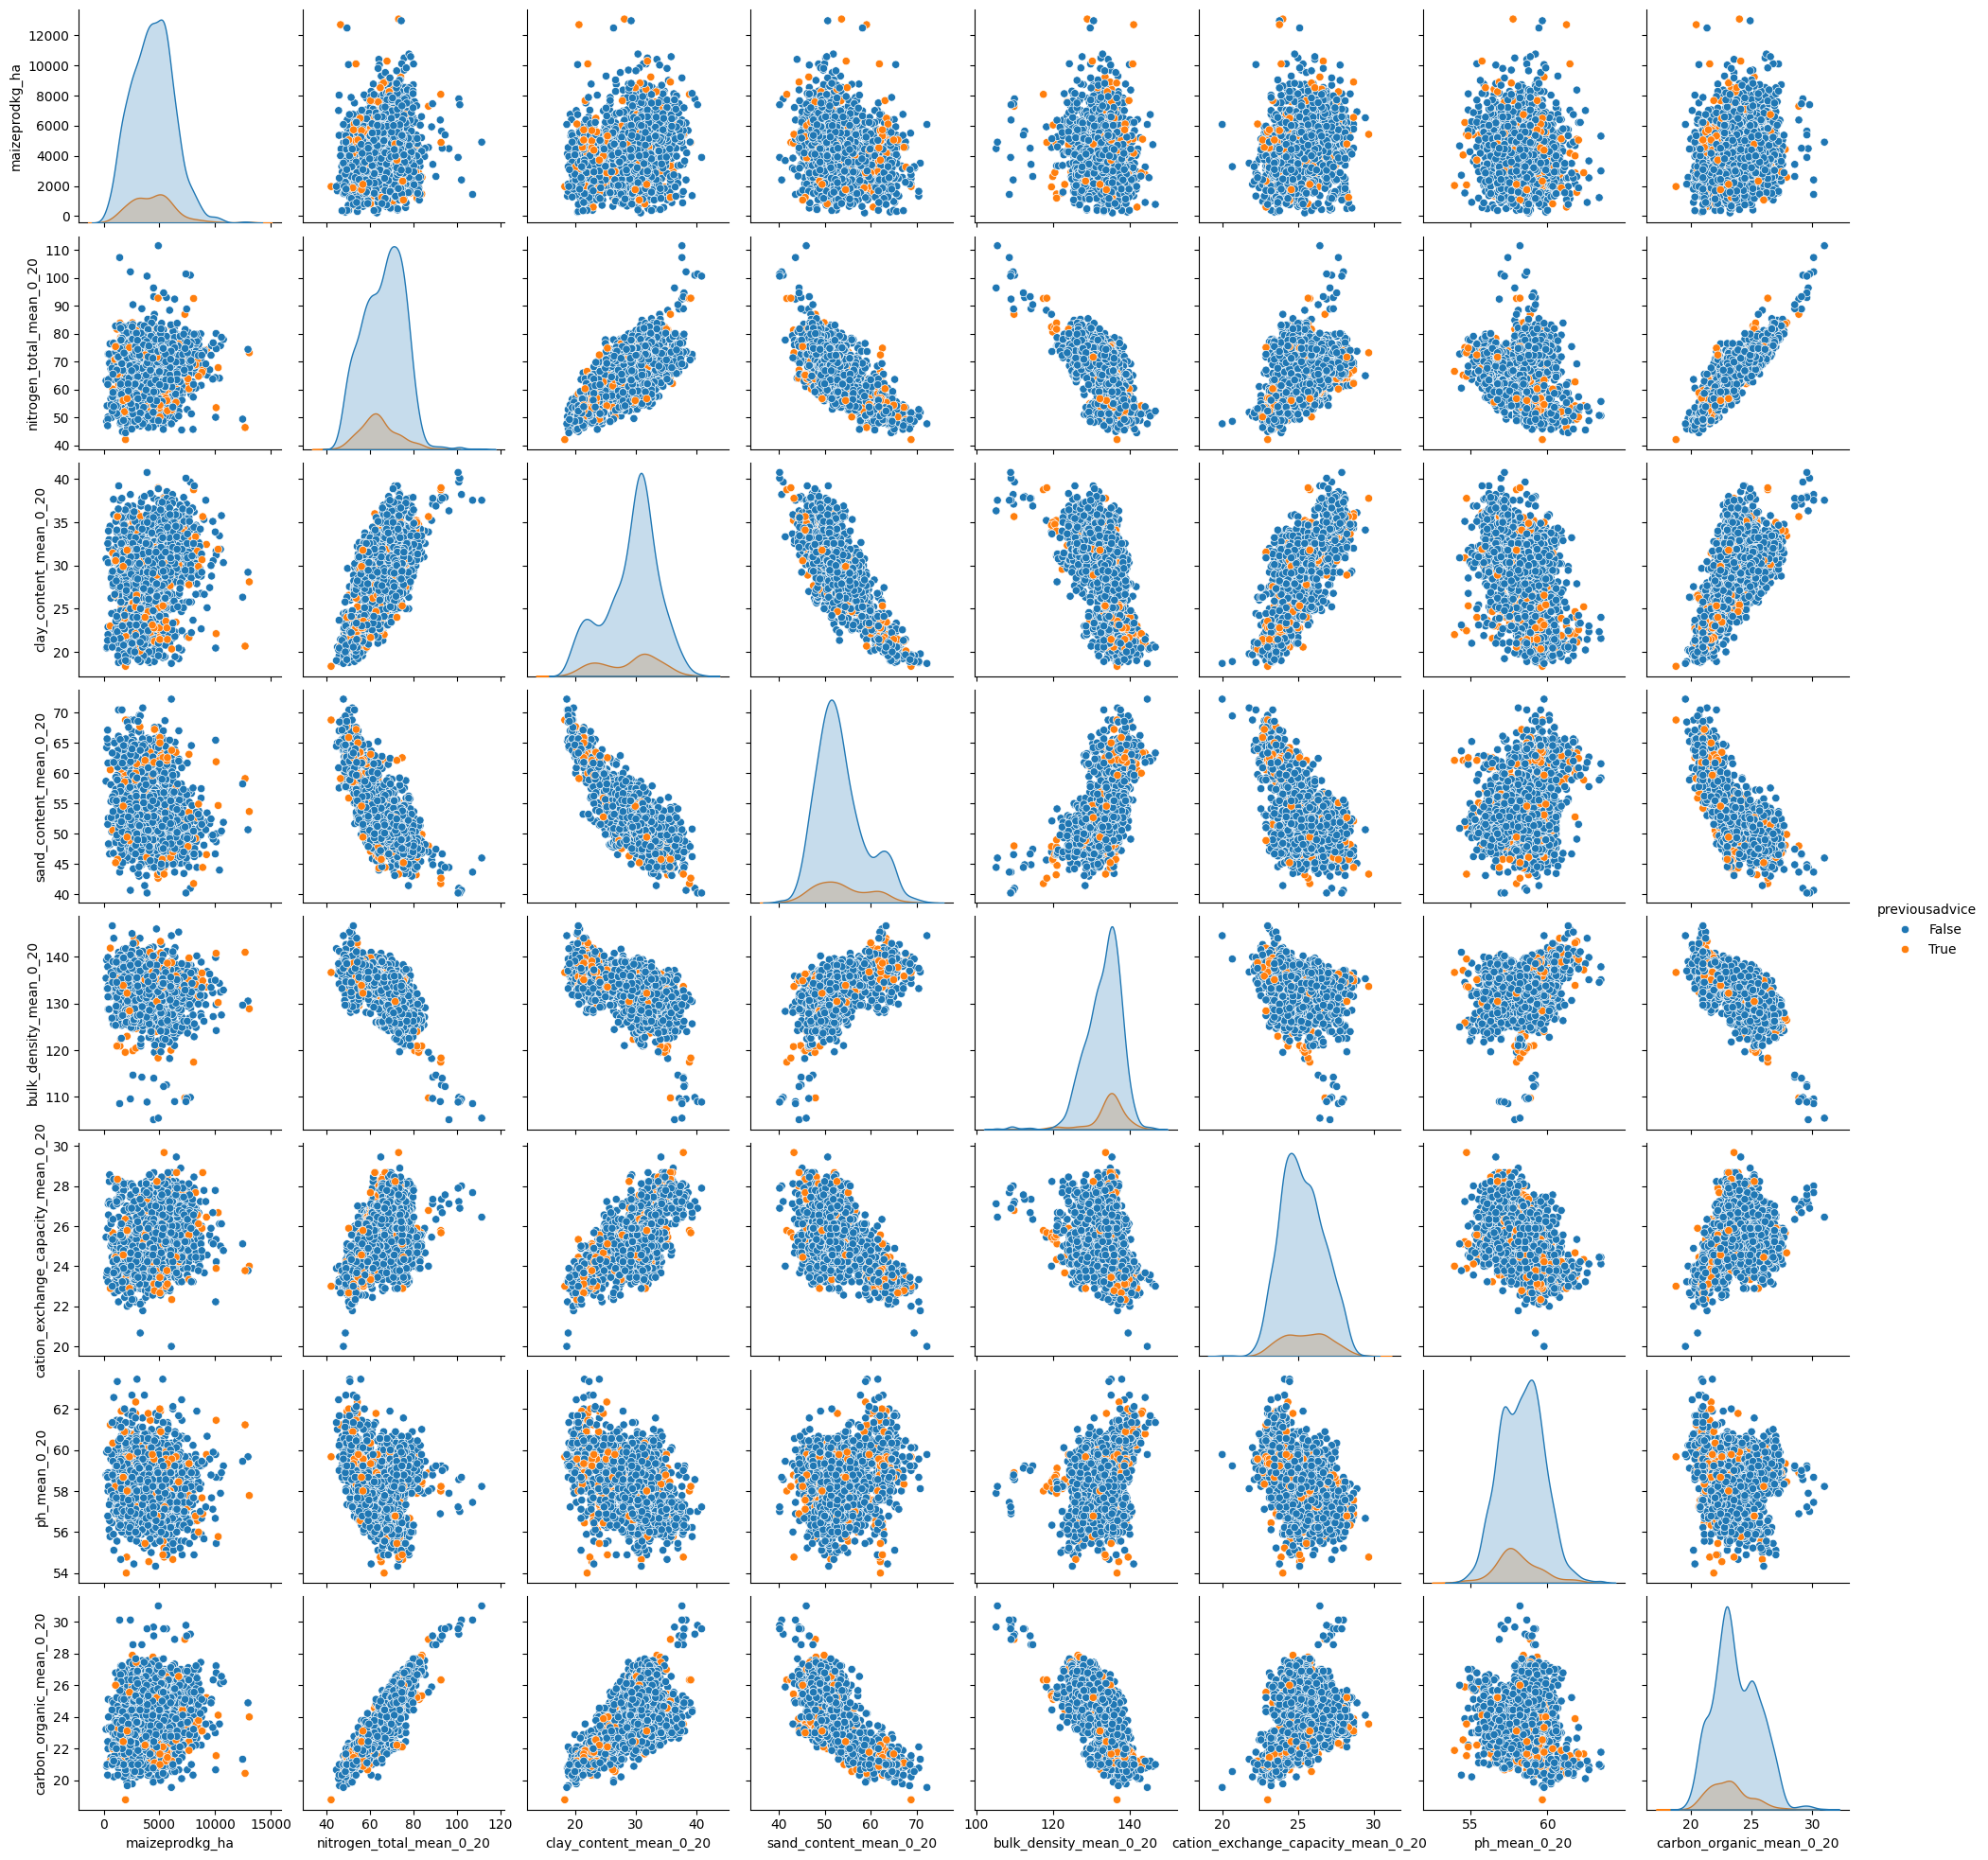

In [26]:
# Soil info
sns.pairplot(
    data=data_subset[['previousadvice', 'maizeprodkg_ha']+soil_columns],
    hue='previousadvice'
)

In [27]:
columns_to_drop.extend(['nitrogen_total_mean_0_20'])

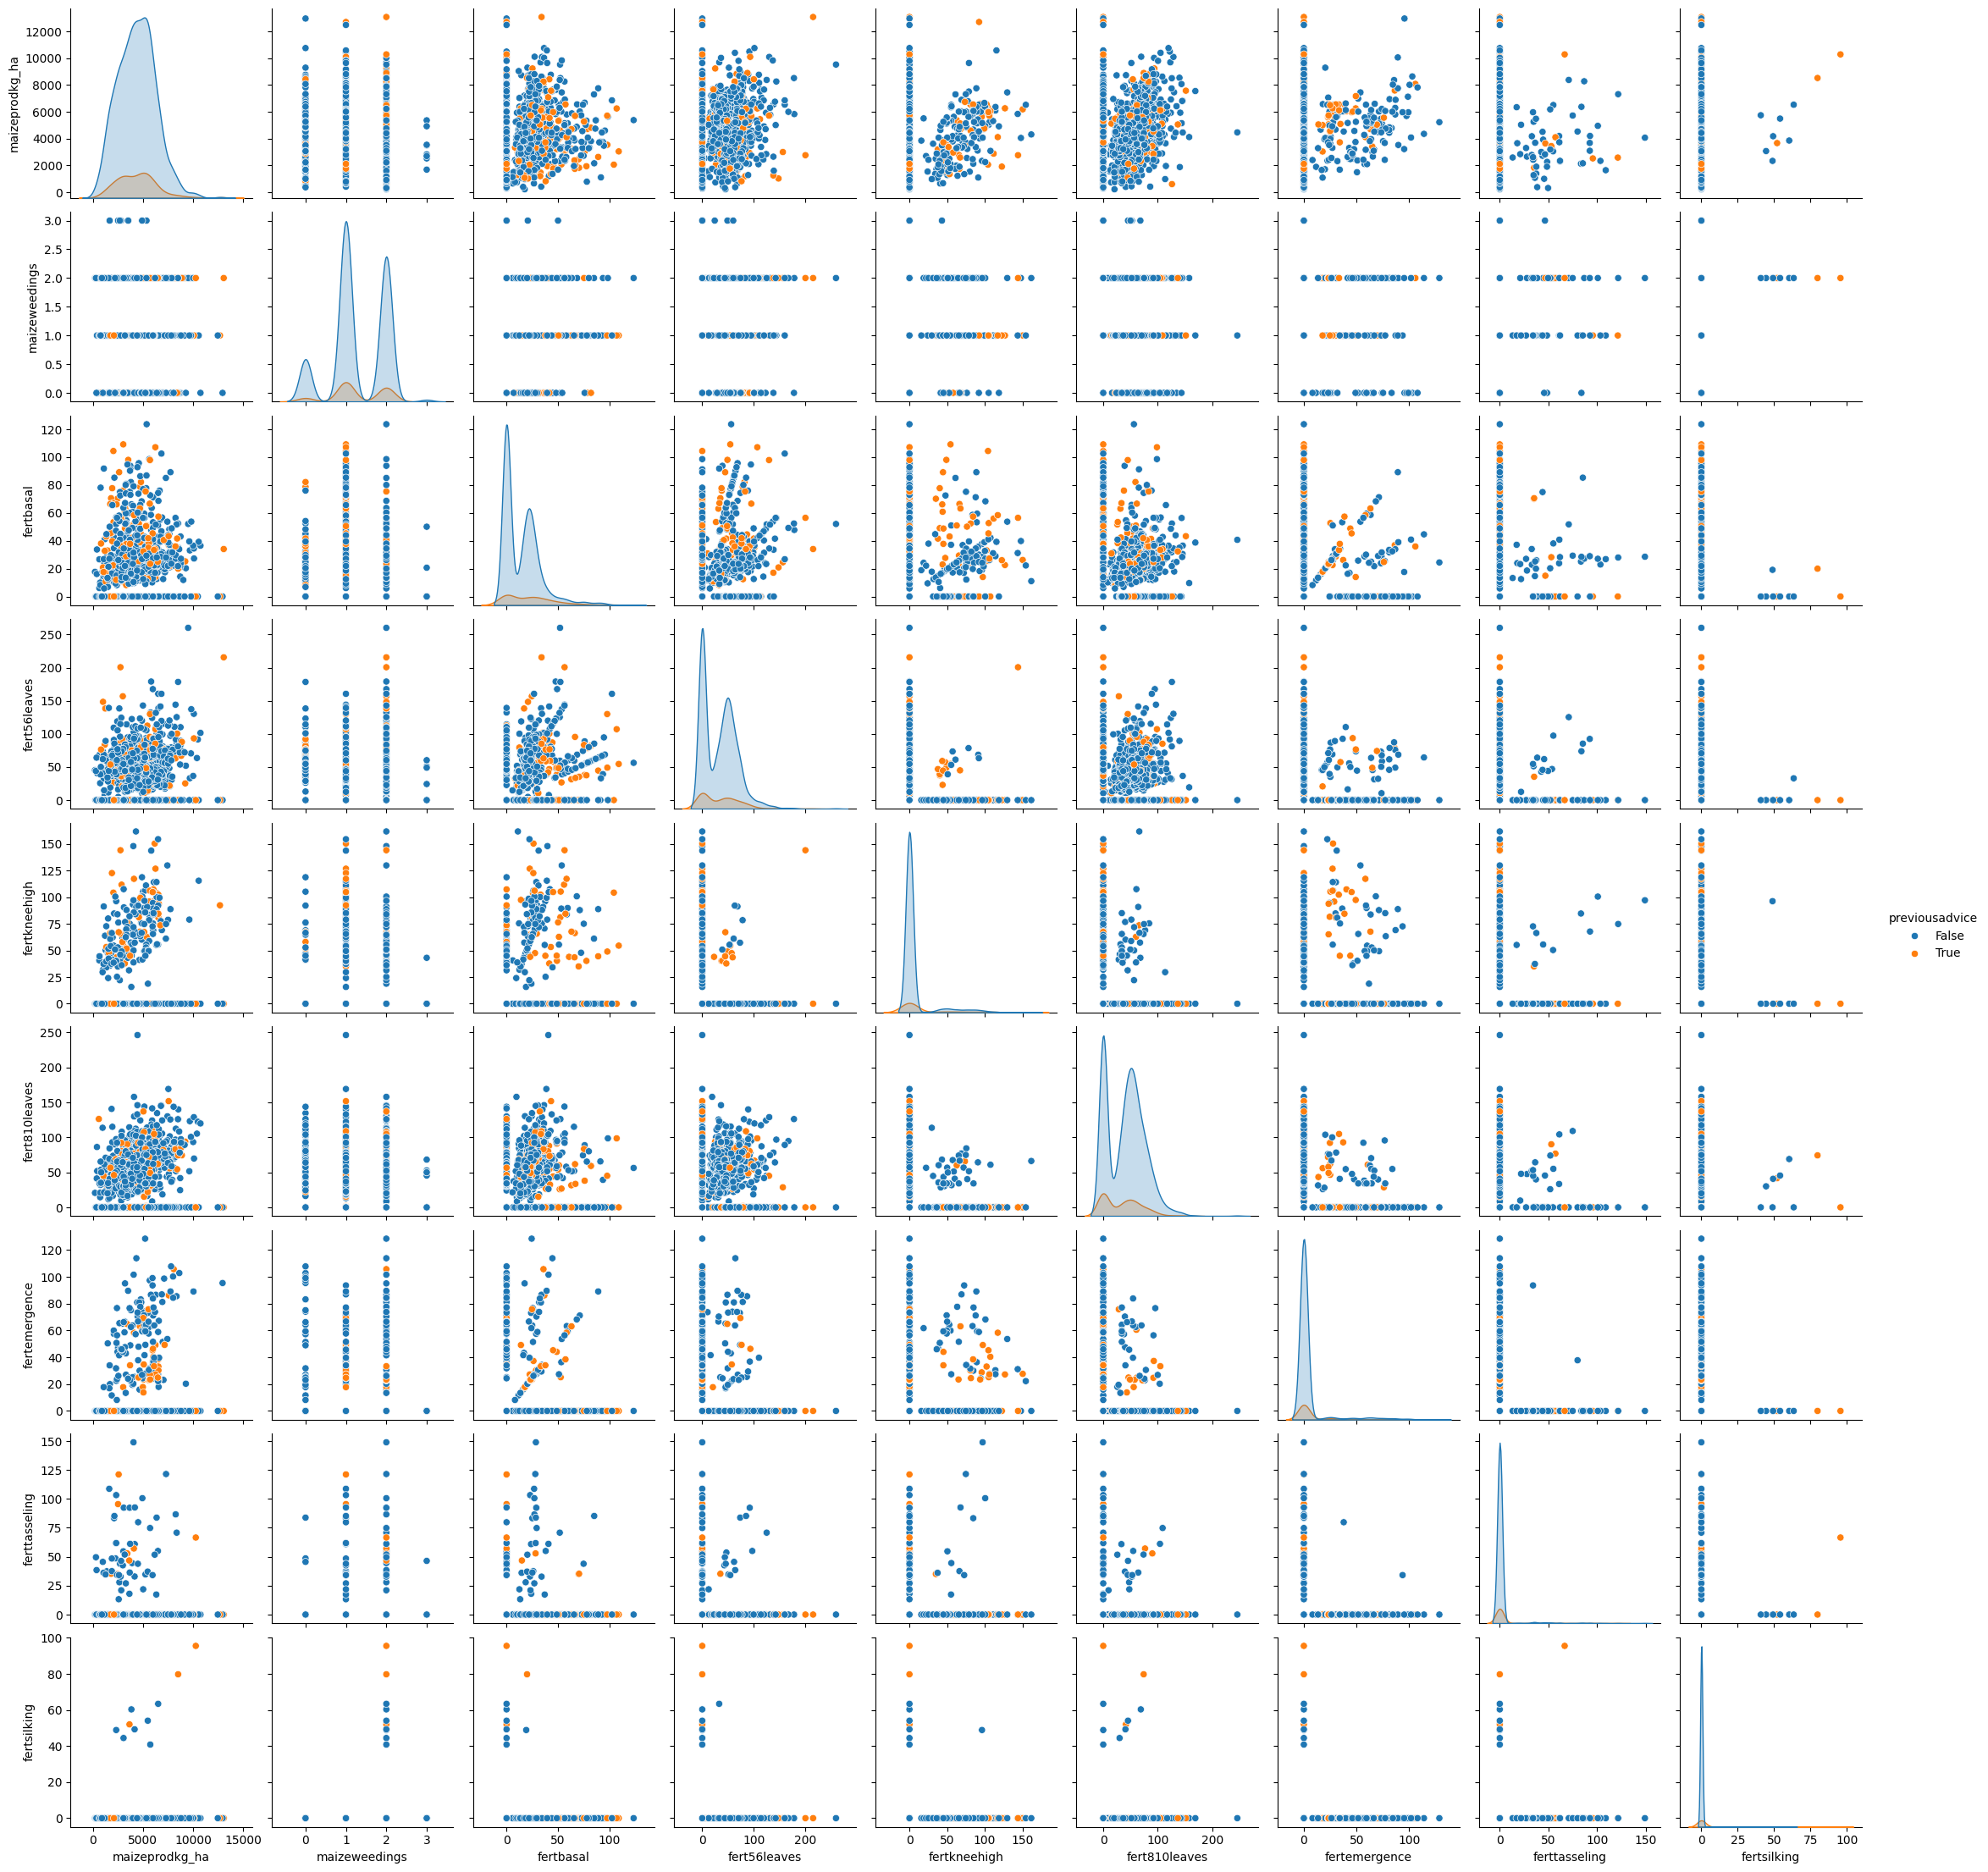

In [28]:
# Management info 
sns.pairplot(
    data=data_subset[
        ['previousadvice', 'maizeprodkg_ha', 'maizeweedings',
        'fertbasal', 'fert56leaves', 'fertkneehigh',
       'fert810leaves', 'fertemergence', 'ferttasseling', 'fertsilking']
    ],
    hue='previousadvice'
)

In [29]:
data_subset = data_subset.drop(columns=columns_to_drop)

## Rename columns
The columns represent individual variables that are included in one group. For example, there are multiple variables for the weather factor, same with soil, and fertilizer info. The columns will be renamed so that the first three characters represent what is the group they belong to.

In [30]:
# Rename columns
data_subset = data_subset.rename(columns={
    'clay_content_mean_0_20': 'soilclay', 'sand_content_mean_0_20': 'soilsand',
    'bulk_density_mean_0_20': 'soildensity', 'cation_exchange_capacity_mean_0_20': 'soilcec',
    'ph_mean_0_20': 'soilph', 'carbon_organic_mean_0_20': 'soiloc', 
    'season_tmean': 'wthtmean', 'season_srad': 'wthsrad', 'season_prec': 'wthprec', 
    'season_rainydays': 'wthrainydays', 'season_maxdryspell': 'wthmaxdryspell',
    'maizeweedings': 'weedings', 'maizeprodkg_ha': 'prodkgha'
})

In [31]:
data_subset = data_subset.dropna()
data_subset.columns = data_subset.columns.str.replace('_', '')

In [32]:
data_subset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1917 entries, 0 to 3753
Data columns (total 50 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   prodkgha                 1917 non-null   float64
 1   weedings                 1917 non-null   float64
 2   soilclay                 1917 non-null   float64
 3   soilsand                 1917 non-null   float64
 4   soildensity              1917 non-null   float64
 5   soilcec                  1917 non-null   float64
 6   soilph                   1917 non-null   float64
 7   soiloc                   1917 non-null   float64
 8   wthtmean                 1917 non-null   float64
 9   wthsrad                  1917 non-null   float64
 10  wthprec                  1917 non-null   float64
 11  wthrainydays             1917 non-null   float64
 12  wthmaxdryspell           1917 non-null   int64  
 13  previousadvice           1917 non-null   bool   
 14  genderfemale             1917

In [33]:
data_subset.to_pickle('data/maize-subset-clean-lineariterpwth.pkl')

# Causal model

In [33]:
import networkx as nx
nx.algorithms.d_separated = nx.algorithms.d_separation.is_d_separator
nx.d_separated = nx.algorithms.d_separation.is_d_separator
from dowhy import CausalModel

Even though we would like to include all the variables, including them all would cause to have many edges, and this would cause the effect identification take forever. Therefore, we will reduce the number of variables in the model.

In [34]:
# Soil
soil_vars = [
    # 'soilclay', 'soilsand', 'soildensity', 'soilcec', 'soilph', 
    'soiloc'
]
# Weather
wth_vars = [
    'wthtmean', 'wthprec', 
    # 'wthsrad', 'wthrainydays', 'wthmaxdryspell'
]
# Fertilizer
fert_vars = [
    'fertbasal', 'fert56leaves', 'fertkneehigh', 'fert810leaves', 
    'fertemergence', 'ferttasseling', 'fertsilking'
]
data_subset['ferttotal'] = data_subset[fert_vars].sum(axis=1)
fert_vars = ['ferttotal']
# Varieties
variety_vars = [
    'vardk777', 'vardkc9089', 'varlocalvariety', 'varmeruhb513', 
    'varpan53', 'varpan691', 'varsc403', 'varsc627', 'varsc719', 
    'varuh615', 'varuh6303', 'varzms606'
]
# Field history
history_vars = [
    'histmaize', 'histnocrop', 'histlegume', 'histoilseed', 
    # 'histrootandtuber'
]
# Residue
residue_vars = ['resburn', 'resfeedtoanimals', 'resincorporateinthesoil', 'resleaveonfield']
data_subset['resonfield'] =  data_subset[['resincorporateinthesoil', 'resleaveonfield']].any(axis=1)
residue_vars = ['resonfield', 'resburn']
# Technology access
tech_vars = ['techhandhoe', 'techploughcattle', 'techtractor']
# Herbicide
herb_vars = ['herbicidepost', 'herbicidepre']
data_subset['herbicide'] = data_subset[herb_vars].any(axis=1)
herb_vars = ['herbicide']

In [35]:
# Define all the edges
edges_list = []
# Soil -> Yield
edges_list.extend([(v, 'prodkgha') for v in soil_vars])
# Soil -> Fertilization
edges_list.extend([(vs, vf) for vs, vf in product(soil_vars, fert_vars)])
# Soil -> Advice
edges_list.extend([(v, 'previousadvice') for v in soil_vars])
# Weather -> Yield
edges_list.extend([(v, 'prodkgha')for v in wth_vars])
# Weather -> Pest and Diseases
edges_list.extend([(v, 'pestdisease')for v in wth_vars])
# Weather -> Advice
edges_list.extend([(v, 'previousadvice')for v in wth_vars])
# Variety -> Pest and Diseases
edges_list.extend([(v, 'pestdisease') for v in variety_vars])
# Variety -> Yield
edges_list.extend([(v, 'prodkgha') for v in variety_vars])
# Residue -> Yield
edges_list.extend([(v, 'prodkgha') for v in residue_vars])
# Herbicide -> Yield
edges_list.extend([(v, 'prodkgha') for v in herb_vars])
# Herbicide -> Weeding
edges_list.extend([(v, 'weedings') for v in herb_vars])
# Weeding -> Yield
edges_list.extend([('weedings', 'prodkgha')]) 
# Technology -> Fertilizer
edges_list.extend([(vt, vf) for vt, vf in product(tech_vars, fert_vars)])
# Technology -> Variety
edges_list.extend([(vt, vv) for vt, vv in product(tech_vars, variety_vars)])
# Technology -> Herbicide
edges_list.extend([(vt, vf) for vt, vf in product(tech_vars, herb_vars)])
# Technology -> Pest and diseases
edges_list.extend([(v, 'pestdisease') for v in tech_vars])
# Technology -> Advice
edges_list.extend([(v, 'previousadvice') for v in tech_vars])
# Technology -> History
edges_list.extend([(vt, vf) for vt, vf in product(tech_vars, history_vars)])
# Gender -> Technology
edges_list.extend([('genderfemale', v) for v in tech_vars])
# Gender -> Land size
edges_list.extend([('genderfemale', 'fieldsize')]) 
# Gender -> History
edges_list.extend([('genderfemale', v) for v in history_vars])
# Gender -> Advice
edges_list.extend([('genderfemale', 'previousadvice')]) 
# Land size -> Technology
edges_list.extend([('fieldsize', v) for v in tech_vars])
# Land size -> Weeding
edges_list.extend([('fieldsize', 'weedings')]) 
# Land size -> Advice
edges_list.extend([('fieldsize', 'previousadvice')]) 
# History -> Pest and diseases
edges_list.extend([(v, 'pestdisease') for v in history_vars])
# History -> Yield
edges_list.extend([(v, 'prodkgha') for v in history_vars])
# History -> Advice
edges_list.extend([(v, 'previousadvice') for v in history_vars])
# History -> Fertilizer
edges_list.extend([(vh, vf) for vh, vf in zip(history_vars, fert_vars)])
# Fertilizer  -> Yield
edges_list.extend([(v, 'prodkgha') for v in fert_vars])
# Pest and diseases -> Yield
edges_list.extend([('pestdisease', 'prodkgha')]) 

# Advice -> Management
edges_list.extend([('previousadvice', v) for v in residue_vars])
edges_list.extend([('previousadvice', v) for v in fert_vars])
edges_list.extend([('previousadvice', v) for v in variety_vars])
edges_list.extend([('previousadvice', v) for v in herb_vars])
edges_list.extend([('previousadvice', 'weedings')]) 
edges_list.extend([('previousadvice', 'pestdisease')])

edges_list

[('soiloc', 'prodkgha'),
 ('soiloc', 'ferttotal'),
 ('soiloc', 'previousadvice'),
 ('wthtmean', 'prodkgha'),
 ('wthprec', 'prodkgha'),
 ('wthtmean', 'pestdisease'),
 ('wthprec', 'pestdisease'),
 ('wthtmean', 'previousadvice'),
 ('wthprec', 'previousadvice'),
 ('vardk777', 'pestdisease'),
 ('vardkc9089', 'pestdisease'),
 ('varlocalvariety', 'pestdisease'),
 ('varmeruhb513', 'pestdisease'),
 ('varpan53', 'pestdisease'),
 ('varpan691', 'pestdisease'),
 ('varsc403', 'pestdisease'),
 ('varsc627', 'pestdisease'),
 ('varsc719', 'pestdisease'),
 ('varuh615', 'pestdisease'),
 ('varuh6303', 'pestdisease'),
 ('varzms606', 'pestdisease'),
 ('vardk777', 'prodkgha'),
 ('vardkc9089', 'prodkgha'),
 ('varlocalvariety', 'prodkgha'),
 ('varmeruhb513', 'prodkgha'),
 ('varpan53', 'prodkgha'),
 ('varpan691', 'prodkgha'),
 ('varsc403', 'prodkgha'),
 ('varsc627', 'prodkgha'),
 ('varsc719', 'prodkgha'),
 ('varuh615', 'prodkgha'),
 ('varuh6303', 'prodkgha'),
 ('varzms606', 'prodkgha'),
 ('resonfield', 'prodkgha

In [36]:
causal_graph = nx.DiGraph(edges_list)
# As some factors are represented by multiple variables (e.g. Variety), 
# we will create a simplified graph that will be the one used when drawing.
graph_to_draw = nx.DiGraph({(cause[:3], effect[:3]) for cause, effect in edges_list})

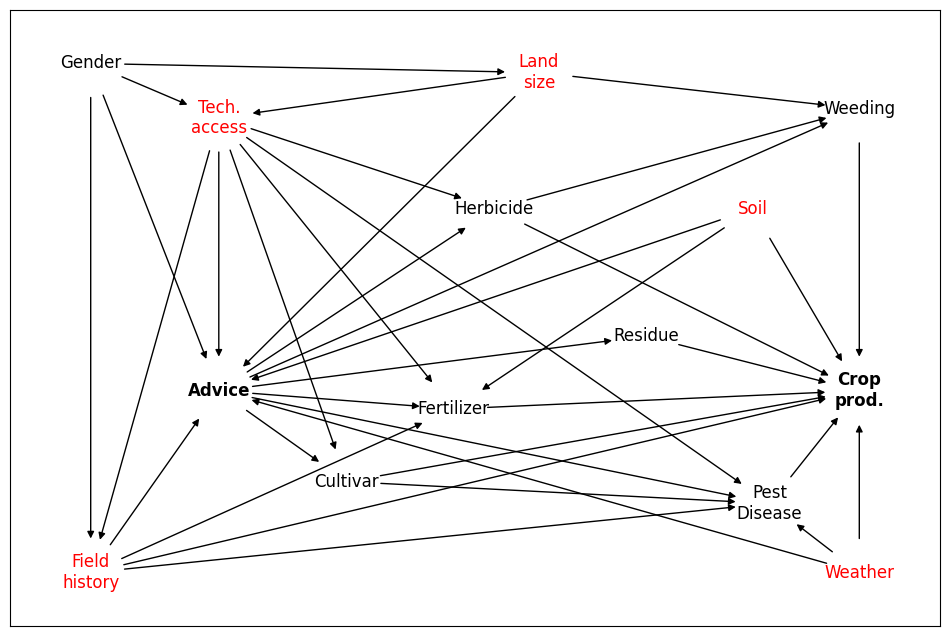

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

labels = {
    'soi': 'Soil', 'wth': 'Weather', 'var': 'Cultivar', 
    'her': 'Herbicide', 'wee': 'Weeding', 'tec': 'Tech.\naccess',
    'gen': 'Gender', 'fie': 'Land\nsize', 'his': 'Field\nhistory',
    'pre': 'Advice', 'pro': 'Crop\nprod.', 'res': 'Residue',
    'pes': 'Pest\nDisease', 'fer': 'Fertilizer'
}
pos ={
    'pro': [0.0, 0.0], 'soi': [-.5, 2], 'wth': [0, -2], 'tec': [-3, 3], 
    'var': [-2.4, -1], 'fie': [-1.5, 3.5], 'gen': [-3.6, 3.6], 'wee': [0., 3.1],
    'pre': [-3, 0.], 'fer': [-1.9, -0.2], 'his': [-3.6, -2], 'res': [-1., .6],
    'her': [-1.71, 2.00],  'pes': [-0.42, -1.24],
}
# I'll color the nodes that I already know are the identified adjustment set
adj_set = ['tec', 'fie', 'his', 'soi', 'wth']
nx.draw_networkx(
    graph_to_draw, ax=ax, labels=labels, pos=pos, node_size=1200, 
    node_shape='s', node_color='#ffffff00', 
    font_weight={node: 'bold' if node in ['pre', 'pro'] else 'normal' for node in labels.keys()},
    font_color={node: 'r' if node in adj_set else 'k' for node in labels.keys()},
)

In [38]:
model = CausalModel(
   data=data_subset,
   treatment="previousadvice",
   outcome="prodkgha",
   graph="\n".join(nx.generate_gml(causal_graph))
)

## Identify effect

In [39]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
─────────────────(E[prodkgha|techploughcattle,histlegume,fieldsize,soiloc,hist ↪
d[previousadvice]                                                              ↪

↪                                                                        
↪ nocrop,histoilseed,wthprec,wthtmean,histmaize,techhandhoe,techtractor])
↪                                                                        
Estimand assumption 1, Unconfoundedness: If U→{previousadvice} and U→prodkgha then P(prodkgha|previousadvice,techploughcattle,histlegume,fieldsize,soiloc,histnocrop,histoilseed,wthprec,wthtmean,histmaize,techhandhoe,techtractor,U) = P(prodkgha|previousadvice,techploughcattle,histlegume,fieldsize,soiloc,histnocrop,histoilseed,wthprec,wthtmean,histmaize,techhandhoe,techtractor)

### Estimand : 2
Estimand name: iv
No such va


Three types of effects can be estimated. The different effect estimates respond to different questions, and their importance deppend on why we are estimating the effect.

- **ATE**: the average treatment effect. it is the average effect if the entire population were treated versus if the entire population were not. It is useful to answer to the question **What would be the average effect if the entire population were treated?**
- **ATT**: the average treatment effect on the treated. It's the effect on the treated group compared to what would have happened to that same group if they hadn't received the treatment. It reponds to the quesiton **What was the average effect on THOSE THAT RECEIVED the treatment?**, which rephrased could be **What would have happened (on average) if the ones that received the treatmed had not received it?**. This question is important when the effectiveness of the intervention has to be evaluated.
- **ATC**: the average treatment effect on the control group. It's the effect on the control group if they had received the treatment, compared to their actual outcome (not receiving it). It would answer to the question **What would have been the effect of the treatment on those that did not receive the treatment?**

## Propensity Score Matching effect estimate

The propensity score is the probality of an instance to receive the treatment conditional on the value of some confounders. The propensity score matching technique estimates effects by matching an instance to that with the closest propensity score. This method requires the propensity score to be claculated. A good estimation of propensity should provide a match for each sample, and should yield covariate balance after matching

### Functions to estimate and evaluate PS

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [41]:
# Check data balance using the standarized mean differences on the Adjustment set
feature_names = identified_estimand.backdoor_variables['backdoor']

def get_smd(model, feature_names=feature_names, pscol='propensity_score',
            treatcol= 'previousadvice', treat_groups=[True, False]):
    tmp_df = model._data.copy()
    difs_list = []
    for _, row in tmp_df.loc[tmp_df[treatcol].isin(treat_groups)].iterrows():
        comp_row = tmp_df.loc[
            (tmp_df.loc[tmp_df.previousadvice != row.previousadvice, pscol] - row.propensity_score).abs().idxmin()
        ]
        difs_list.append({f: float(row[f]) - float(comp_row[f]) for f in feature_names})
    smd_values = pd.DataFrame({
        'Before Matching': (tmp_df.groupby(tmp_df.previousadvice)[feature_names].mean().diff().iloc[-1]) / \
                np.sqrt(tmp_df.groupby(tmp_df.previousadvice)[feature_names].var().mean()),
        'After Matching':
            pd.DataFrame.from_records(difs_list).mean() / 
                np.sqrt(tmp_df.groupby(tmp_df.previousadvice)[feature_names].var().mean())
    })
    return smd_values.abs()
    
def estimate_propensity_score(model, feature_names=feature_names, treatcol='previousadvice',
                             class_weight={True: 4.0, False: 1}):
    # To avoid model internal variables to modify the original dataframe
    model._data = data_subset.copy()
    
    
    numeric_features = list(model._data[feature_names].select_dtypes(include='number').columns)
    categorical_features = list(set(feature_names) - set(numeric_features))
    
    model._data.loc[:, numeric_features] = StandardScaler().fit_transform(model._data[numeric_features]).astype(np.float32)
    model._data[categorical_features] = model._data[categorical_features].astype(np.float32)
    
    X = model._data.loc[:, feature_names]
    y = data_subset.loc[:, 'previousadvice']
    
    # import cbpys
    # cbps = cbpys.CBPS(
    #     X=model._data[feature_names].values,
    #     W=data_subset['previousadvice'].values,
    #     estimand="ATE",
    #     intercept=True,
    #     noi=False,
    #     # niter=1000,
    #     # lr=1e-1,
    #     # reg=1e-5,
    #     # svd=None,
    # )
    # weights = cbps.weights(numpy=True)
    
    classifier = LogisticRegression(penalty='l2', class_weight=class_weight)
    fit_params = {
    }
    classifier.fit(X, y, sample_weight=fit_params.get('sample_weight'))
    print(classification_report(
        y_true=model._data.loc[:, 'previousadvice'],
        y_pred=classifier.predict(model._data.loc[:, feature_names])
    ))
    
    model._data['propensity_score'] = classifier.predict_proba(model._data[feature_names])[:,1]
    model._data = model._data.loc[(model._data.propensity_score > .2) & (model._data.propensity_score < .8)]
    print(f'{len(model._data)} samples')

def evaluate_propensity_scores(model, feature_names=feature_names, treatcol='previousadvice',
                              pscol='propensity_score', treat_groups=[True, False]):
    # Evaluate matching ranges
    fig, ax = plt.subplots(1, 1)
    sns.histplot(
        model._data.loc[model._data.previousadvice],
        x='propensity_score', ax=ax, label='Yes',
        stat ='count', fill=False, element='step', bins=np.linspace(0, 1, 21)
    )
    sns.histplot(
        model._data.loc[~model._data.previousadvice],
        x='propensity_score', ax=ax, label='No',
        stat ='count', fill=False, element='step', bins=np.linspace(0, 1, 21)
    )
    ax.legend(title='Previous advice')
    ax.set_xlim(model._data.propensity_score.min(), model._data.propensity_score.max()) 
    ax.set_xlabel('Propensity score')
    display(ax)
    display(get_smd(model, treat_groups=treat_groups).style.map(lambda v: 'color:red' if v >.1 else 'color:black'))

### Estimate ATE

#### Propensity score estimation

              precision    recall  f1-score   support

       False       0.93      0.89      0.91      1684
        True       0.37      0.48      0.42       233

    accuracy                           0.84      1917
   macro avg       0.65      0.68      0.66      1917
weighted avg       0.86      0.84      0.85      1917

1453 samples


<Axes: xlabel='Propensity score', ylabel='Count'>

,Before Matching,After Matching
techploughcattle,0.350783,0.114229
histlegume,0.327650,0.070030
fieldsize,0.120105,0.002203
soiloc,0.107537,0.036310
histnocrop,0.019305,0.066120
histoilseed,0.311080,0.017097
wthprec,0.027769,0.050464
wthtmean,0.207723,0.057349
histmaize,0.284936,0.041810
techhandhoe,0.227808,0.162618


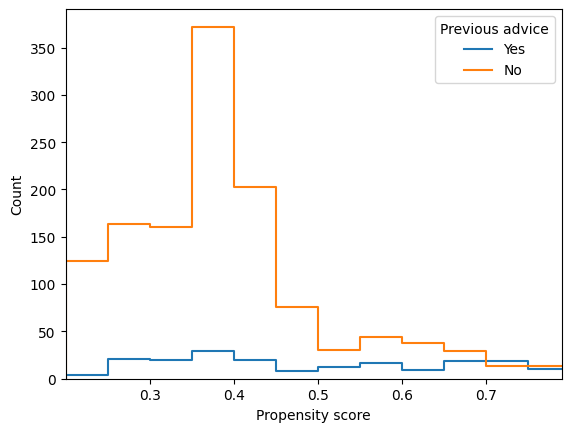

In [42]:
# Estimate and evaluate Propensity Score
estimate_propensity_score(model, class_weight={True: 5, False: 1})
evaluate_propensity_scores(model)

#### Effect estimation

In [43]:
# Estimate 
method_name = "backdoor.propensity_score_matching"
ate_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='ate',
)
print('ATE = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
    ate_estimate.value, *ate_estimate.get_confidence_intervals())
)

ATE = 155 kg/ha, CI = -256 - 477 kg/ha


#### Refutate the estimate

placebo_treatment_refuter


Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:155.418907627446
New effect:-9.28509183111356
p value:0.96



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:155.418907627446
New effect:155.418907627446
p value:1.0



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:155.418907627446
New effect:177.6349144855594
p value:0.8400000000000001



/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_refuters/add_unobserved_common_cause.py:366: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  new_data.loc[rel_interval <= w_random, treatment_name] = (


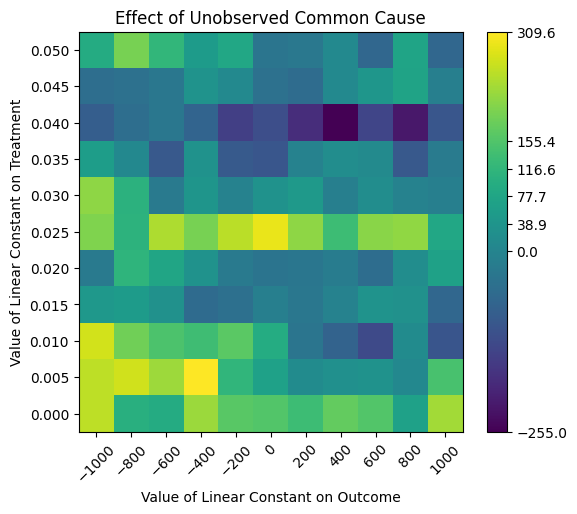

In [44]:
# Refute
def refute_estimate(estimate, model=model, identified_estimand=identified_estimand):
    print("placebo_treatment_refuter")
    res_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="placebo_treatment_refuter", show_progress_bar=True, placebo_type="permute"
    )
    print(res_refuter)
    res_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="random_common_cause", show_progress_bar=True, placebo_type="permute"
    )
    print(res_refuter)
    res_refuter = model.refute_estimate(
        identified_estimand, estimate,
        method_name="data_subset_refuter", show_progress_bar=True, placebo_type="permute"
    )
    print(res_refuter)
    res_unobserved_auto = model.refute_estimate(
        identified_estimand, estimate, method_name="add_unobserved_common_cause",
        confounders_effect_on_treatment="binary_flip", confounders_effect_on_outcome="linear",
        effect_strength_on_treatment=np.linspace(0, 0.05, 11), 
        effect_strength_on_outcome=np.linspace(-1000, 1000, 11)
    )
refute_estimate(ate_estimate)

### Estimate ATT

#### Propensity score estimation

              precision    recall  f1-score   support

       False       0.93      0.89      0.91      1684
        True       0.37      0.48      0.42       233

    accuracy                           0.84      1917
   macro avg       0.65      0.68      0.66      1917
weighted avg       0.86      0.84      0.85      1917

1453 samples


<Axes: xlabel='Propensity score', ylabel='Count'>

,Before Matching,After Matching
techploughcattle,0.350783,0.122618
histlegume,0.327650,0.064434
fieldsize,0.120105,0.000474
soiloc,0.107537,0.025753
histnocrop,0.019305,0.134479
histoilseed,0.311080,0.000000
wthprec,0.027769,0.064064
wthtmean,0.207723,0.079379
histmaize,0.284936,0.161567
techhandhoe,0.227808,0.056614


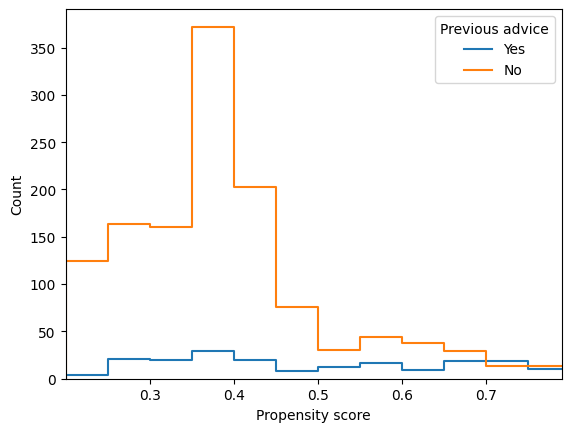

In [45]:
estimate_propensity_score(model, class_weight={True: 5., False: 1})
evaluate_propensity_scores(model, treat_groups=[True])

#### Effect estimation

In [46]:
att_estimate = model.estimate_effect(
    identified_estimand, method_name=method_name,
    confidence_intervals=True, target_units='att',
)
print('ATT = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
    att_estimate.value, *att_estimate.get_confidence_intervals())
)

ATT = 456 kg/ha, CI = 41 - 976 kg/ha


#### Refute the estimate

placebo_treatment_refuter


Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a Placebo Treatment
Estimated effect:456.11194544790214
New effect:24.370395896870885
p value:0.8400000000000001



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Add a random common cause
Estimated effect:456.11194544790214
New effect:456.11194544790226
p value:1.0



Refuting Estimates:   0%|          | 0/100 [00:00<?, ?it/s]

Refute: Use a subset of data
Estimated effect:456.11194544790214
New effect:396.127770589806
p value:0.62



/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/dowhy/causal_refuters/add_unobserved_common_cause.py:366: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  new_data.loc[rel_interval <= w_random, treatment_name] = (


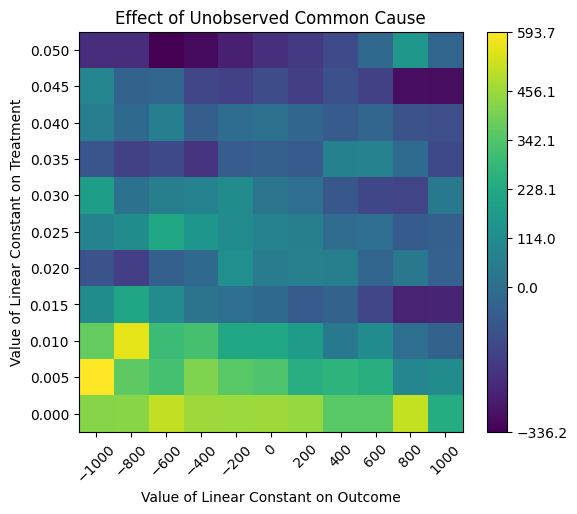

In [47]:
refute_estimate(att_estimate)

### Conclusions

No average significant average treatment effect when considering the whole sample, but there might be a significant treatment effect when only considering the treated. Therefore, the advice could be working for the ones receiving it, but it might not work for all.

**The method is incredibly sensitive to the propensity score estimate**

## Causal ML effect estimate

### Double Machine Learning (DML)

DML makes the following structural equation assumptions on the data generating process:

$$
\begin{split}Y =~& \theta(X) \cdot T + g(X, W) + \epsilon ~~~&~~~ \mathbb{E}[\epsilon | X, W] = 0 \\
T =~& f(X, W) + \eta & \mathbb{E}[\eta \mid X, W] = 0 \\
~& \mathbb{E}[\eta \cdot \epsilon | X, W] = 0\end{split}
$$

What is particularly attractive about DML is that it makes no further structural assumptions on $g$ and $f$ and estimates them non-parametrically using arbitrary non-parametric Machine Learning methods. Our goal is to estimate the constant marginal CATE $\theta(X)$

In [48]:
from econml.dml import LinearDML, CausalForestDML, NonParamDML
from econml.inference import BootstrapInference
from econml.cate_interpreter import SingleTreeCateInterpreter
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestClassifier

### First stage estimators ($g$ and $f$)

The first stage estimators are the ones that predict the outcome and treatment based on the confounders and effect modifiers.

In [51]:
feature_names = identified_estimand.backdoor_variables['backdoor']
# feature_names = data_subset.drop(columns=['previousadvice', 'prodkgha']).columns
numeric_features = list(data_subset[feature_names].select_dtypes(include='number').columns)
categorical_features = list(set(feature_names) - set(numeric_features))

T = data_subset.previousadvice.values
numeric_transformer = StandardScaler().fit(data_subset[numeric_features])
X = W = np.hstack([
    numeric_transformer.transform(data_subset[numeric_features]),
    data_subset[categorical_features].values
])
Y = data_subset.prodkgha.astype(np.float32).values

X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(X, Y, T, random_state=24)

In [53]:
parameters = {
    'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
    # 'n_estimators': [100, 500, 1000]
}
reg = RandomForestRegressor()
grid_search = GridSearchCV(reg, parameters)
grid_search.fit(X_train, y_train)
pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head()

,params,mean_test_score
5,"{'max_depth': 10, 'min_samples_split': 20}",0.189073
8,"{'max_depth': 20, 'min_samples_split': 20}",0.179331
7,"{'max_depth': 20, 'min_samples_split': 10}",0.178909
4,"{'max_depth': 10, 'min_samples_split': 10}",0.176932
3,"{'max_depth': 10, 'min_samples_split': 5}",0.174285


In [54]:
# Best: max_depth=20, min_samples_split=20
f_y = grid_search.best_estimator_
r2_score(y_true=y_test, y_pred=f_y.predict(X_test))

In [55]:
parameters = {
    'min_samples_split': [5, 10, 20], 'max_depth':[5, 10, 20],
    # 'n_estimators': [100, 1000], 
    'class_weight': [{True: 1, False: 1}, {True: 3, False: 1}, {True: 5, False: 1}]
}
cls = RandomForestClassifier()
grid_search = GridSearchCV(cls, parameters, scoring='roc_auc')
grid_search.fit(X_train, t_train)
pd.DataFrame(grid_search.cv_results_)[['params', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head()

,params,mean_test_score
24,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.854768
22,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.853873
16,"{'class_weight': {True: 3, False: 1}, 'max_dep...",0.853250
25,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.850869
21,"{'class_weight': {True: 5, False: 1}, 'max_dep...",0.849921


In [56]:
# Best: max_depth=20, min_samples_split=10, class_weight={False: 1, True: 5}
f_t = grid_search.best_estimator_
print(classification_report(y_true=t_test, y_pred=f_t.predict(X_test)))

              precision    recall  f1-score   support

       False       0.90      0.94      0.92       418
        True       0.44      0.29      0.35        62

    accuracy                           0.86       480
   macro avg       0.67      0.62      0.64       480
weighted avg       0.84      0.86      0.85       480



### LinearDML estimator

In [57]:
ldml_est = LinearDML(
    model_y=f_y, 
    model_t=f_t,
    discrete_treatment=True
)
X = W = pd.DataFrame(X, columns=numeric_features+categorical_features)
ldml_est.fit(
    Y=Y, T=T, X=X, W=W, inference=BootstrapInference(n_bootstrap_samples=100)
)
print('ATE = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
    ldml_est.ate(X), *ldml_est.ate_interval(X))
)

/home/quint021/mba-tanzania/venv/lib/python3.12/site-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")


ATE = 172 kg/ha, CI = -1517 - 1861 kg/ha


In [58]:
def print_cate(est, condition):
    if isinstance(condition, pd.Series):
        condition = condition.values
    print('CATE = {0:.0f} kg/ha, CI = {1:.0f} - {2:.0f} kg/ha'.format(
        est.ate(X.iloc[condition]), *est.ate_interval(X.iloc[condition], alpha=.05))
    )
# ATT
print_cate(ldml_est, T==1)

CATE = 199 kg/ha, CI = -915 - 1312 kg/ha


#### Heterogeneous effects on the treated units 

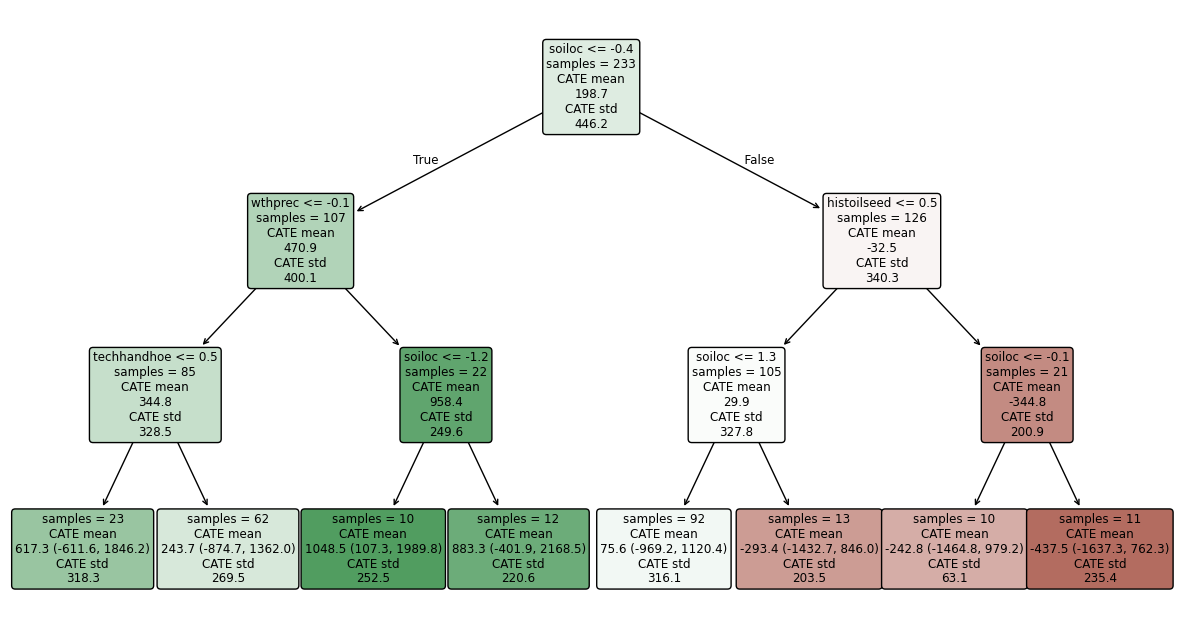

In [81]:
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=3, min_samples_leaf=10)
intrp.interpret(ldml_est, X[T==1])
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
intrp.plot(feature_names=X.columns, precision=1)

- A Signigicantly positive effect of the treatment (107-1990 kg/ha) on the units with the lowest soil feritlity (soc < -1.2sd) and close to or above average precipitation (prec <= -0.1sd).
- A mostly positive effect (-402 - 2168 kg/ha) on soils with low soil feritility (-1.2sd < soc < -0.4) and close to or above average precipitation (prec <= -0.1sd).
- Average positive effect (-612 - 1846 kg/ha) on units with higher technology access (do not prepare soils by hand) and close to or above average precipitation (prec <= -0.1sd).

#### Heterogeneous effects on the untreated units 

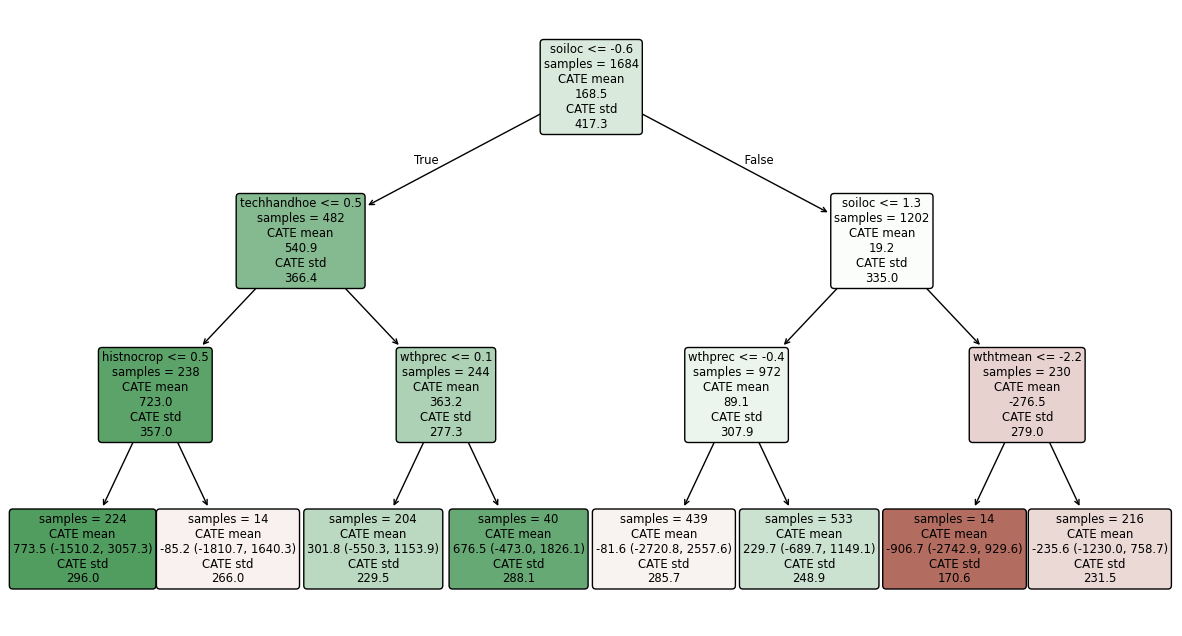

In [67]:
intrp.interpret(ldml_est, X[T==0])
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
intrp.plot(feature_names=X.columns, precision=1)

- There could be a mostly postivie effect for units with higher techonlogy access (use tractor or animals to plough), closer to or above average precipitation (prec > 0.1sd) and lower fertility in their soils (soc < -0.6sd).

### Causal Forest DML Estimator

In [68]:
cf_est = CausalForestDML(
    model_t=f_t, model_y=f_y,
    criterion='het', n_estimators=500,       
    min_samples_leaf=10, max_depth=10, max_samples=0.5,
    discrete_treatment=True,
)
cf_est.fit(Y, T, X=X, W=W)

In [70]:
# ATE
print_cate(cf_est, np.ones(T.shape).astype(bool))

CATE = 108 kg/ha, CI = -858 - 1073 kg/ha


In [71]:
# ATT
print_cate(cf_est, T==1)

CATE = 141 kg/ha, CI = -864 - 1146 kg/ha


#### Heterogeneous effects on the treated units 

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


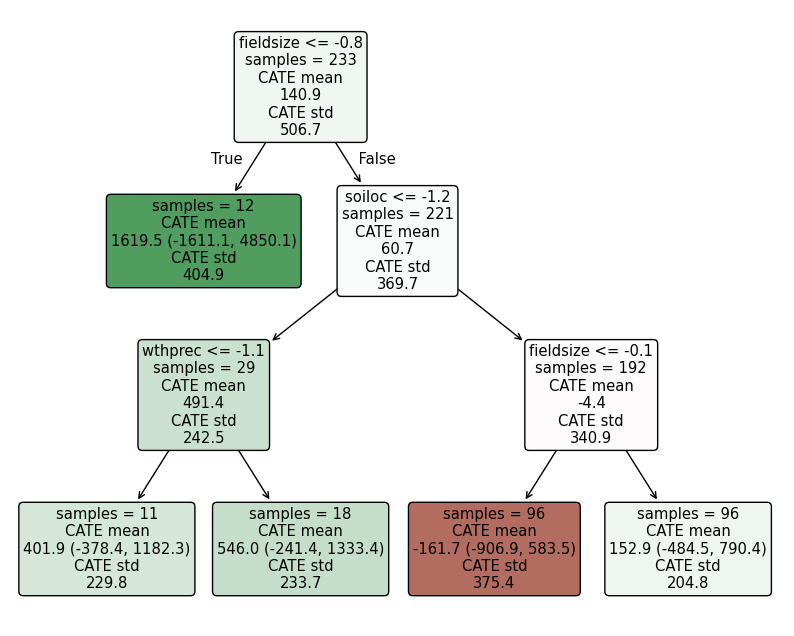

In [82]:
intrp.interpret(cf_est, X[T==1])
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
intrp.plot(feature_names=X.columns, precision=1)

- Mostly positive effect on units with the lowest soil fertility (soc<-1.2sd)

#### Heterogeneous effects on the untreated units 

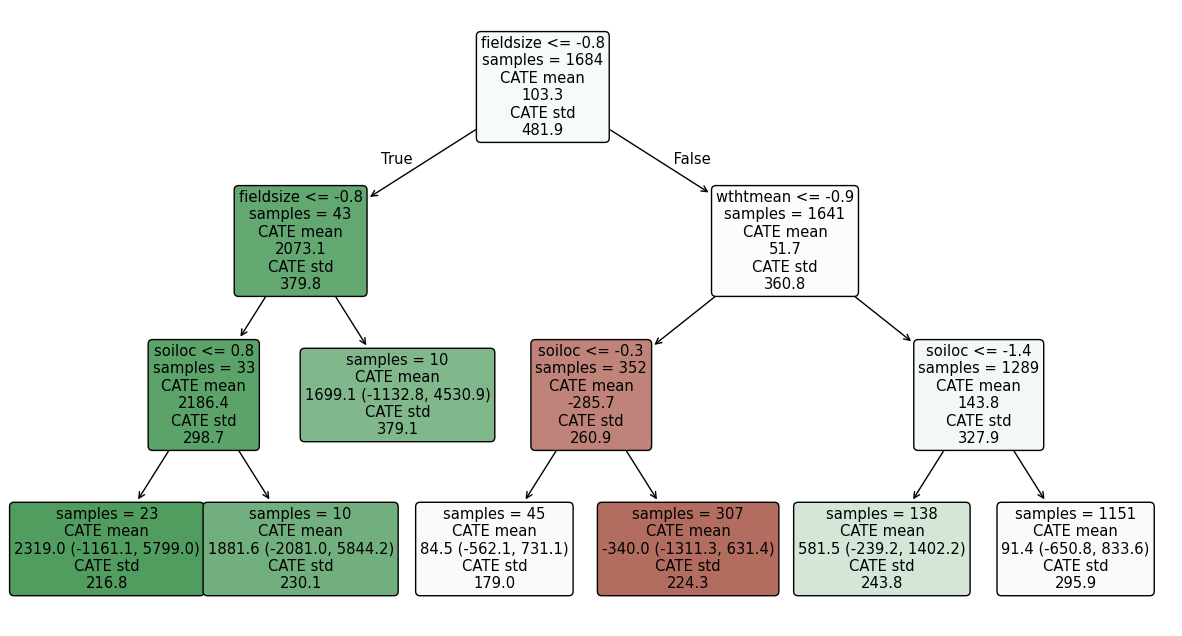

In [80]:
intrp.interpret(cf_est, X[T==0])
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
intrp.plot(feature_names=X.columns, precision=1)

- There seems to be a mostly positive effect on the smallest fields (size<-0.8sd)
- On non-so-small fields (size>-0.8sd) with not the lowest temperatures (tmean>-0.9sd) and the least fertile soils (soc<-1.4sd), there could be a positive effect.